## Image processing - food classifier

### Part I - Baseline Evaluation

Using our own collected data as the input to the classification model. Compare the results versus the results from the Food-101 dataset

First test the model is loaded

Model initialized, using device: cuda


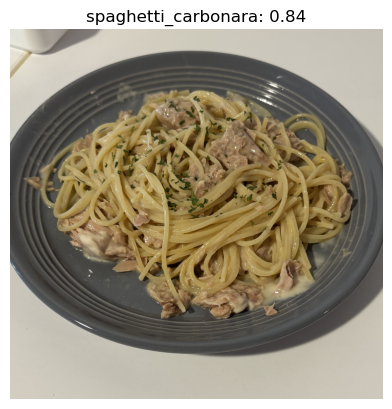

In [1]:
import shutil
import sys
sys.path.insert(0, './src')
from models.classifier import FoodClassifier
from utils import calculate_metrics
import plot

# Initialize the classification model
model = FoodClassifier()

# Model testing, predict a single image
example_image = './data/example.JPG'
results = model.predict_single(example_image)
plot.single_image(example_image, title=f"{results['label']}: {results['confidence']:.2f}")

Run prediction directly on our collected dataset as the baseline

Loaded 44 images from ./data/raw
Predicted 44 images in 3.06s


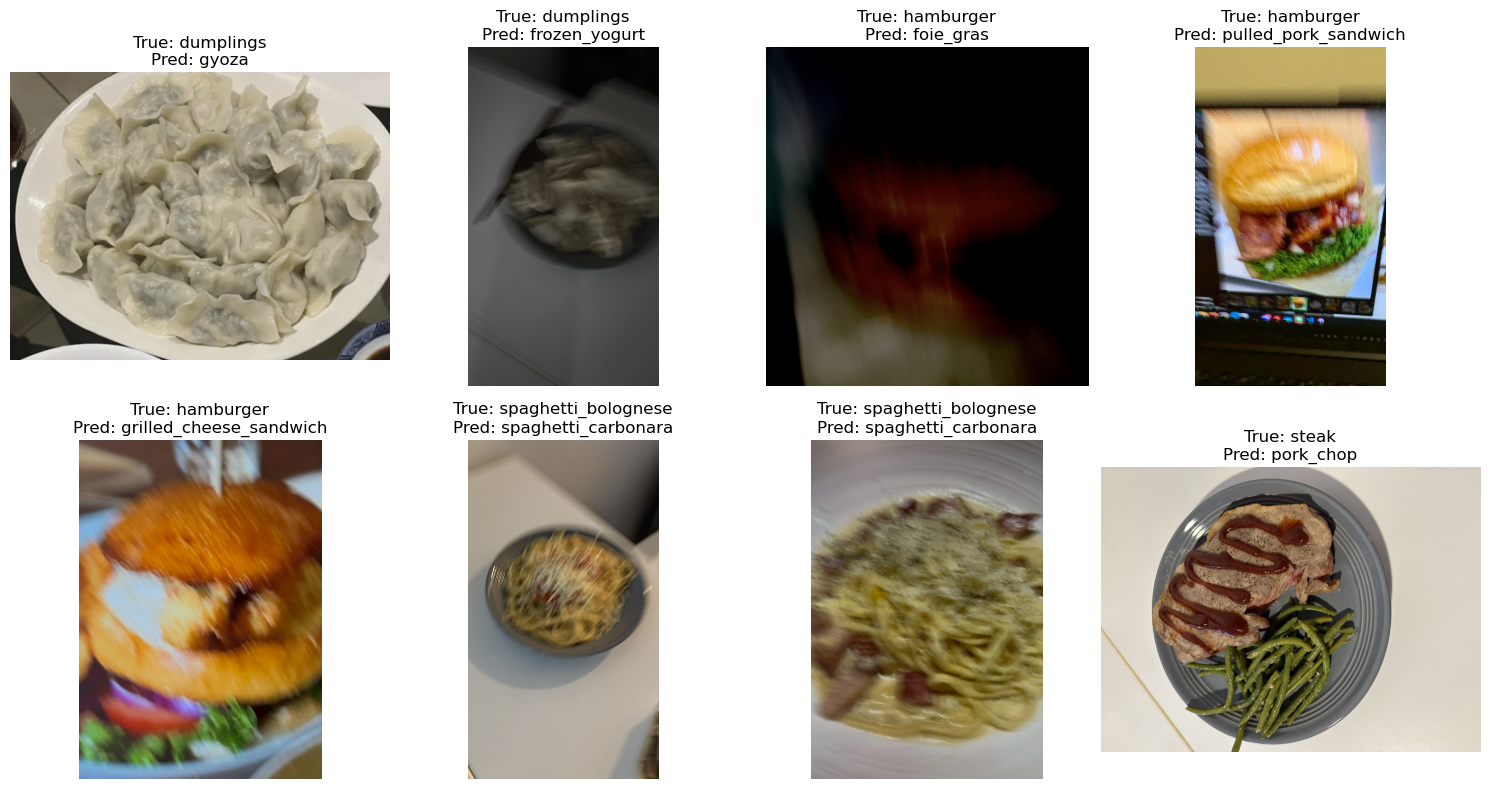

{'accuracy': 0.7727272727272727, 'f1_score': 0.8325757575757575}


In [2]:
dataset_path = './data/raw'
results = model.predict_folder(dataset_path)
plot.wrong_predictions(results, folder = dataset_path)
metrics = calculate_metrics(**results)
print(metrics)

### Part II - Individual Algorithm Evaluation

Process our collected data with the image processing algorithms. Use them as the input to the model

In [ ]:
from preprocessing.lowlight import gamma, CLAHE, SSRetinex
#from preprocessing.deblurr import f1, f2, f3
#form preprocessing.downscale import d1, d2, d3
from utils import preprocess_folder

output_path = './data/preprocessed'

for func in [gamma, CLAHE, SSRetinex]:
    preprocess_folder(func, input_dir=dataset_path, output_dir=output_path)
    results = model.predict_folder(output_path)
    metrics = calculate_metrics(**results)
    print(f"Metrics for {func.__name__}: {metrics}")
    plot.wrong_predictions(results, folder = output_path)
shutil.rmtree(output_path)

# for func in [f1, f2, f3]:
# for func in [d1, d2, d3]:

Loaded 44 images from ./data/raw
Predicted 44 images in 3.21s
Metrics for gamma: {'accuracy': 0.7727272727272727, 'f1_score': 0.8325757575757575}
Loaded 44 images from ./data/raw
Predicted 44 images in 3.25s
Metrics for CLAHE: {'accuracy': 0.7727272727272727, 'f1_score': 0.8325757575757575}
Loaded 44 images from ./data/raw
Predicted 44 images in 3.19s
Metrics for SSRetinex: {'accuracy': 0.7727272727272727, 'f1_score': 0.8325757575757575}


### Part III - Combination Search

### Part IV - Model Fine-Tuning